# 01 — Cleaning and EDA (2026 refresh)

**Question this notebook answers:** what is in the Kepler Objects of Interest table, what is missing, and what may a model legitimately see?

**Inputs:** `data/raw/cumulative_kaggle_snapshot.csv` (9,564 KOIs, the 2020 project's snapshot; provenance in `data/README.md`).
**Outputs:** `data/processed/koi_clean.parquet` (every KOI, cleaned, leakage columns labelled) and figures in `reports/figures/eda/`.

> **What changed since 2020** (details: *notes/Research Log/2026-08-24 Review 01_cleaning_eda*)
> - One load path, through `kepler.data`; no database cells, no inert "raw" cells.
> - Column names are the archive's own (`koi_period`), with readable labels for charts.
> - `koi_score` stays numeric; missingness becomes an indicator instead of a placeholder string.
> - Nothing is dropped silently: the table below shows exactly which rows a `dropna` would cost, by class.
> - Leakage columns (`koi_fpflag_*`, `koi_score`, `koi_pdisposition`, `kepler_name`) are named and kept out of the physics feature set.
> - The 2020 pipeline is reproduced bit-for-bit by `legacy_2020_processed` and checked in `tests/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kepler import data, preprocess, viz
from kepler.data import TARGET, label
from kepler.paths import DATA_PROCESSED, FIGURES

viz.apply_style()
FIG_DIR = FIGURES / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 140)

## 1. Load

The snapshot is read exactly as downloaded and indexed by `kepoi_name`, which is unique (one row per KOI). `kepid` is *not* unique: one star can host several KOIs.

In [2]:
raw = data.load_kaggle_snapshot()
print("shape:", raw.shape, "| unique KOIs:", raw.index.is_unique, "| distinct stars:", raw["kepid"].nunique())
raw[TARGET].value_counts().rename("KOIs").to_frame()

shape: (9564, 49) | unique KOIs: True | distinct stars: 8214


,KOIs
koi_disposition,
FALSE POSITIVE,5023
CONFIRMED,2293
CANDIDATE,2248


### The two Ys

`koi_pdisposition` is the Kepler pipeline's verdict from Kepler data alone (2 classes). `koi_disposition` is the archive's current verdict, which adds follow-up work (3 classes). **The project's target is `koi_disposition`.** The cross-tab shows why the other one can never be a feature.

In [3]:
pd.crosstab(raw[data.PIPELINE_VERDICT], raw[TARGET], margins=True)

koi_disposition,CANDIDATE,CONFIRMED,FALSE POSITIVE,All
koi_pdisposition,,,,
CANDIDATE,2248,2248,0,4496
FALSE POSITIVE,0,45,5023,5068
All,2248,2293,5023,9564


## 2. What is missing

Nulls are not spread evenly. The fitted transit and stellar parameters are missing together for 363 KOIs, the catalogue-delivery columns for 346, and the two sets only partly overlap.

In [4]:
nulls = preprocess.null_report(raw[[c for c in raw.columns if not c.endswith(("_err1", "_err2"))]])
nulls.assign(label=[label(c) for c in nulls.index])

,nulls,share,label
kepler_name,7270,0.760142,Kepler name
koi_score,1510,0.157884,Disposition score
koi_impact,363,0.037955,Impact parameter
koi_depth,363,0.037955,Transit depth [ppm]
koi_prad,363,0.037955,Planet radius [Earth radii]
koi_teq,363,0.037955,Equilibrium temperature [K]
koi_model_snr,363,0.037955,Transit signal-to-noise
koi_srad,363,0.037955,Stellar radius [Solar radii]
koi_slogg,363,0.037955,Stellar surface gravity [log10 cm/s^2]
koi_steff,363,0.037955,Stellar effective temperature [K]


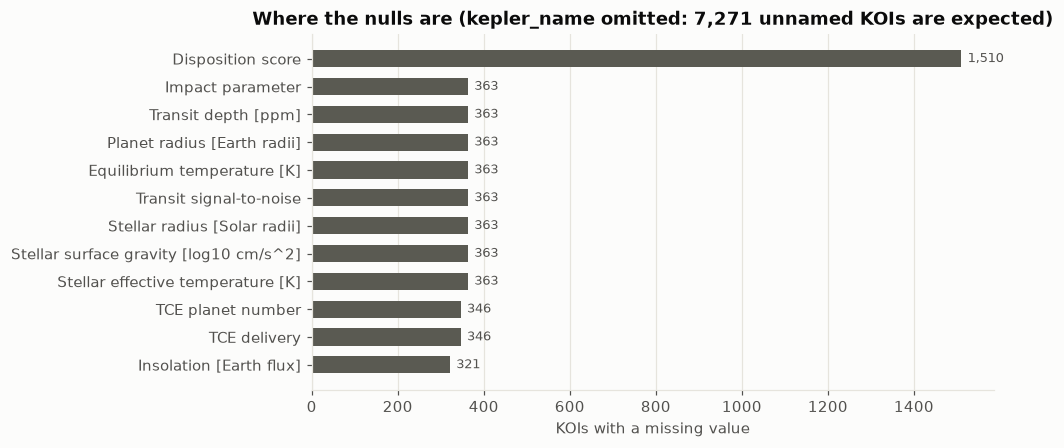

In [5]:
fig, ax = viz.new_figure(8, 4.2)
top = nulls[~nulls.index.isin(["kepler_name"])].head(12).iloc[::-1]
ax.barh([label(c) for c in top.index], top["nulls"], color="#5a5a52", height=0.62)
for y, v in enumerate(top["nulls"]):
    ax.text(v + 15, y, f"{v:,}", va="center", fontsize=8.5, color=viz.TEXT_SECONDARY)
ax.set_xlabel("KOIs with a missing value")
ax.set_title("Where the nulls are (kepler_name omitted: 7,271 unnamed KOIs are expected)")
ax.grid(axis="y", visible=False)
fig.savefig(FIG_DIR / "nulls_by_column.png")
plt.show()

### What `dropna` would cost

The 2020 README said "roughly 363 rows". The pipeline actually removed **619** because its feature set included the delivery columns. Missingness also tracks the label: false positives lose parameters far more often than confirmed planets, so dropping rows shifts the class balance and throws away a signal.

In [6]:
legacy_cost = preprocess.rows_with_nulls_by_class(raw, preprocess.FEATURE_SETS["legacy_2020"][:20])
physics_cost = preprocess.rows_with_nulls_by_class(raw, preprocess.FEATURE_SETS["physics_only"])
pd.concat({"legacy_2020 columns": legacy_cost, "physics_only columns": physics_cost}, axis=1)

legacy_2020 columns                       physics_only columns                      
                               rows dropped share_dropped                 rows dropped share_dropped
koi_disposition                                                                                     
FALSE POSITIVE                 5023     499      0.099343                 5023     300      0.059725
CONFIRMED                      2293       8      0.003489                 2293       1      0.000436
CANDIDATE                      2248     112      0.049822                 2248      63      0.028025
ALL                            9564     619      0.064722                 9564     364      0.038059

## 3. Clean

`preprocess.clean` drops the 22 uncertainty columns (the habitable-zone work reads them from the raw table), keeps `koi_score` numeric, adds `koi_score_missing` and `has_kepler_name`, and adds three delivery dummies. **No rows are removed.**

In [7]:
clean = preprocess.clean(raw)
print("cleaned shape:", clean.shape)
print("leakage columns (never in the physics feature set):", preprocess.LEAKAGE_COLUMNS)
clean.head(3)

cleaned shape: (9564, 32)
leakage columns (never in the physics feature set): ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_score', 'koi_pdisposition', 'kepler_name']


,rowid,kepid,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_score_missing,has_kepler_name,koi_tce_delivname_q1_q16_tce,koi_tce_delivname_q1_q17_dr24_tce,koi_tce_delivname_q1_q17_dr25_tce
kepoi_name,,,,,,,,,,,,,,,,,,,,,
K00752.01,1,10797460,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,4.467,0.927,291.93423,48.141651,15.347,False,True,0,0,1
K00752.02,2,10797460,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,4.467,0.927,291.93423,48.141651,15.347,False,True,0,0,1
K00753.01,3,10811496,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,4.544,0.868,297.00482,48.134129,15.436,False,False,0,0,1


### Why the flags are leakage

Each `koi_fpflag_*` column is one of the reasons the vetting pipeline gave for calling a KOI a false positive. Any flag set almost always means FALSE POSITIVE; no flag almost always means not. A model given the flags is mostly reading the answer.

In [8]:
any_flag = clean[preprocess.FLAG_COLUMNS].max(axis=1).map({0: "no flag", 1: "flag set"})
pd.crosstab(any_flag, clean[TARGET], margins=True)

koi_disposition,CANDIDATE,CONFIRMED,FALSE POSITIVE,All
row_0,,,,
flag set,32,54,4918,5004
no flag,2216,2239,105,4560
All,2248,2293,5023,9564


### Feature sets

Every model notebook must name which set it used. `physics_only` is the honest problem; `with_flags` reproduces the vetting logic; `legacy_2020` is the exact 23-column set the 2020 models saw.

In [9]:
pd.DataFrame(
    {name: {"columns": len(cols), "has flags": any(c in preprocess.FLAG_COLUMNS for c in cols),
            "has provenance": any(c in preprocess.PROVENANCE_COLUMNS or c.startswith("koi_tce_delivname_") for c in cols)}
     for name, cols in preprocess.FEATURE_SETS.items()}
).T

,columns,has flags,has provenance
physics_only,12,False,False
with_flags,16,True,False
with_flags_and_provenance,23,True,True
legacy_2020,23,True,True


## 4. A first look at the data

Colours are fixed per class throughout the project (green = CONFIRMED, amber = CANDIDATE, plum = FALSE POSITIVE) and every class also has its own marker shape.

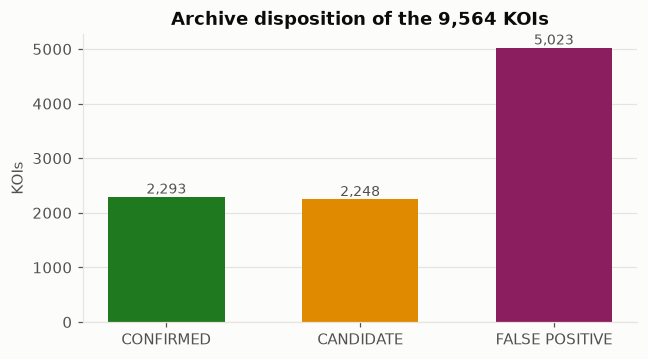

In [10]:
counts = clean[TARGET].value_counts().reindex(viz.CLASS_ORDER)
fig, ax = viz.new_figure(6.5, 3.4)
bars = ax.bar(counts.index, counts.values, color=[viz.class_color(c) for c in counts.index], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 60, f"{v:,}", ha="center", fontsize=9, color=viz.TEXT_SECONDARY)
ax.set_ylabel("KOIs")
ax.set_title("Archive disposition of the 9,564 KOIs")
ax.grid(axis="x", visible=False)
fig.savefig(FIG_DIR / "class_balance.png")
plt.show()

### Where Kepler looked

Right ascension and declination of every KOI: the Kepler field, with its 21-module footprint visible as gaps. The sky is a natural subject, so this is the one place a blue background would be allowed; it does not need one.

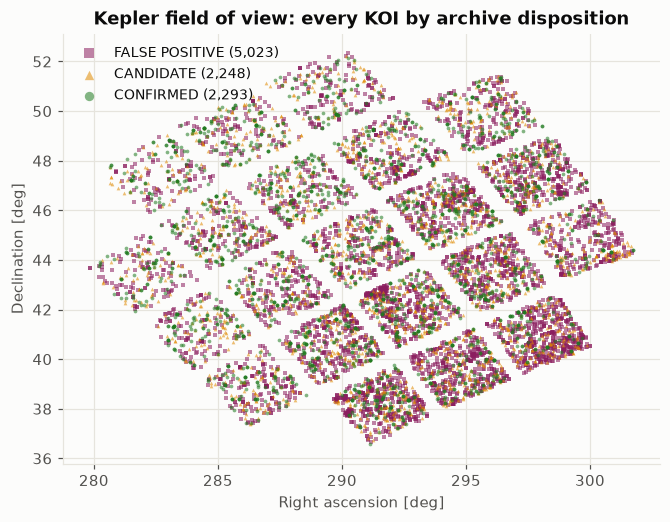

In [11]:
fig, ax = viz.new_figure(7, 6.2)
for cls in viz.CLASS_ORDER[::-1]:
    sub = clean[clean[TARGET] == cls]
    ax.scatter(sub["ra"], sub["dec"], s=6, alpha=0.55, marker=viz.CLASS_MARKERS[cls],
               color=viz.class_color(cls), label=f"{cls} ({len(sub):,})", linewidths=0)
ax.set_xlabel(label("ra")); ax.set_ylabel(label("dec"))
ax.set_title("Kepler field of view: every KOI by archive disposition")
ax.legend(markerscale=2.5, loc="upper left")
ax.set_aspect("equal")
fig.savefig(FIG_DIR / "field_of_view.png")
plt.show()

### Period and radius

Both axes span decades, so they are log-scaled. Confirmed planets cluster below about 4 Earth radii; the large-radius cloud at the top is mostly false positives (eclipsing binaries masquerading as giant planets).

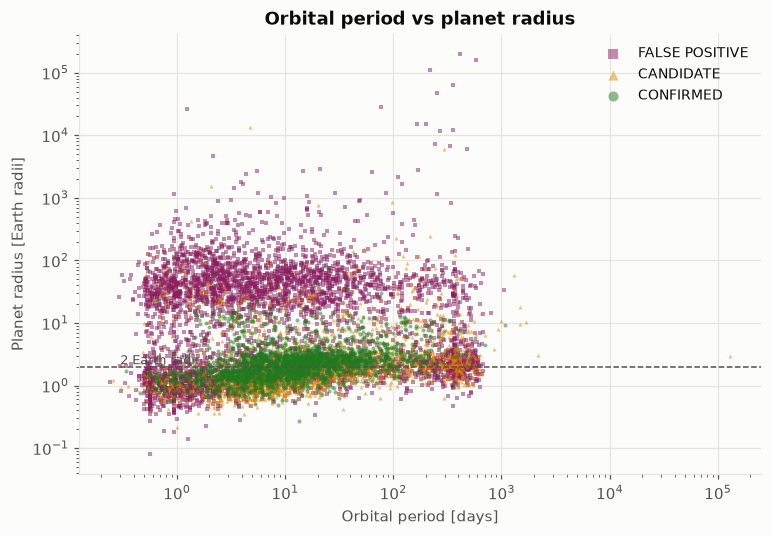

In [12]:
fig, ax = viz.new_figure(8, 5.2)
for cls in viz.CLASS_ORDER[::-1]:
    sub = clean[clean[TARGET] == cls].dropna(subset=["koi_period", "koi_prad"])
    ax.scatter(sub["koi_period"], sub["koi_prad"], s=7, alpha=0.5, marker=viz.CLASS_MARKERS[cls],
               color=viz.class_color(cls), label=cls, linewidths=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(label("koi_period")); ax.set_ylabel(label("koi_prad"))
ax.axhline(2.0, color=viz.TEXT_SECONDARY, lw=1, ls="--")
ax.text(0.3, 2.2, "2 Earth radii", fontsize=8.5, color=viz.TEXT_SECONDARY)
ax.set_title("Orbital period vs planet radius")
ax.legend(markerscale=2.5)
fig.savefig(FIG_DIR / "period_radius.png")
plt.show()

### Insolation and radius: a preview of Phase 4

Insolation (`koi_insol`, Earth = 1) is the quantity habitable-zone limits are defined on. The shaded band is a *flat* approximation of the conservative habitable zone for a Sun-like star from Kopparapu et al. 2013 (inner edge 0.99 AU, outer edge 1.70 AU → about 1.02 to 0.35 Earth flux; the real limits depend on stellar temperature and will be implemented properly in Phase 4). **Provisional.**

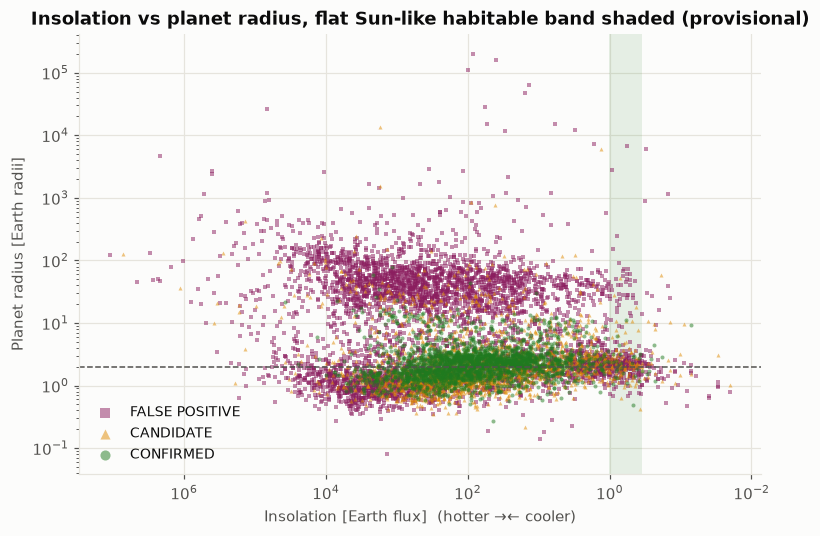

confirmed planets in the flat band: 27 | of which radius <= 2 Earth radii: 13 (provisional)


In [13]:
HZ_INNER, HZ_OUTER = 1 / 0.99**2, 1 / 1.70**2  # flat Sun-like limits, provisional
fig, ax = viz.new_figure(8, 5.2)
ax.axvspan(HZ_OUTER, HZ_INNER, color="#1f7a1f", alpha=0.10, lw=0)
for cls in viz.CLASS_ORDER[::-1]:
    sub = clean[clean[TARGET] == cls].dropna(subset=["koi_insol", "koi_prad"])
    ax.scatter(sub["koi_insol"], sub["koi_prad"], s=7, alpha=0.5, marker=viz.CLASS_MARKERS[cls],
               color=viz.class_color(cls), label=cls, linewidths=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()  # hotter on the left, like a distance-from-star axis
ax.axhline(2.0, color=viz.TEXT_SECONDARY, lw=1, ls="--")
ax.set_xlabel(label("koi_insol") + "  (hotter →← cooler)"); ax.set_ylabel(label("koi_prad"))
ax.set_title("Insolation vs planet radius, flat Sun-like habitable band shaded (provisional)")
ax.legend(markerscale=2.5, loc="lower left")
fig.savefig(FIG_DIR / "insolation_radius.png")
plt.show()

in_band = clean["koi_insol"].between(HZ_OUTER, HZ_INNER)
small = clean["koi_prad"] <= 2.0
print("confirmed planets in the flat band:", int((in_band & clean[TARGET].eq("CONFIRMED")).sum()),
      "| of which radius <= 2 Earth radii:", int((in_band & small & clean[TARGET].eq("CONFIRMED")).sum()), "(provisional)")

### Equilibrium temperature is not independent information

`koi_teq` is derived from `koi_insol` in this table: T ∝ S^¼ with a fixed constant. Keep one of them in the physics feature set, not both, when a model dislikes duplicated columns.

In [14]:
ratio = (clean["koi_teq"] / clean["koi_insol"] ** 0.25).dropna()
print(f"koi_teq / koi_insol^0.25: median {ratio.median():.1f} K, 5th-95th percentile {ratio.quantile(0.05):.1f}-{ratio.quantile(0.95):.1f} K")

koi_teq / koi_insol^0.25: median 255.0 K, 5th-95th percentile 254.7-255.3 K


### How the physical quantities relate

Spearman rank correlation, because most of these columns have heavy tails (a Pearson correlation would be dominated by a handful of extreme values). Diverging scale: purple = negative, green = positive, grey = none.

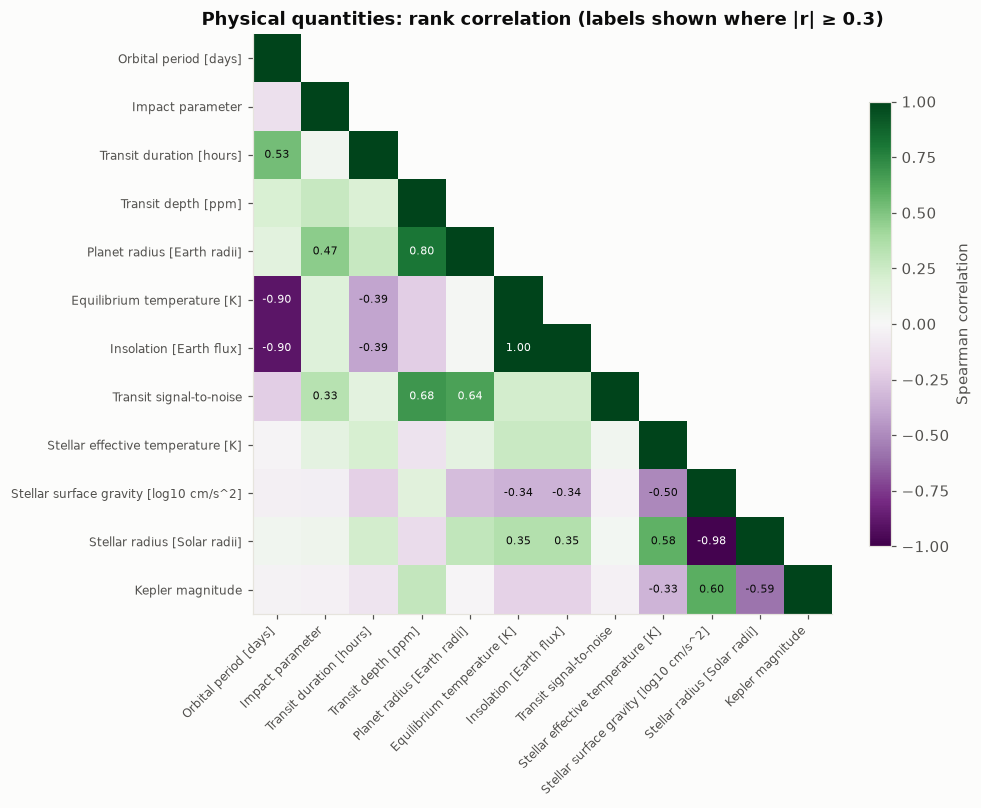

In [15]:
phys = clean[preprocess.PHYSICS_COLUMNS]
corr = phys.corr(method="spearman")
fig, ax = viz.new_figure(8.5, 7)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(np.where(mask, np.nan, corr), cmap="PRGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels([label(c) for c in corr.columns], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([label(c) for c in corr.index], fontsize=8)
for i in range(len(corr)):
    for j in range(i + 1):
        v = corr.iloc[i, j]
        if abs(v) >= 0.3 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v) > 0.6 else viz.TEXT_PRIMARY)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="Spearman correlation")
ax.set_title("Physical quantities: rank correlation (labels shown where |r| ≥ 0.3)")
fig.savefig(FIG_DIR / "correlation_spearman.png")
plt.show()

### Distributions

Heavy-tailed columns are shown on a log axis. This is the picture behind two review findings: a linear model cannot use `koi_insol` or `koi_prad` untransformed (95% of rows sit in a sliver of the standardized range), and `log1p` fixes most of it.

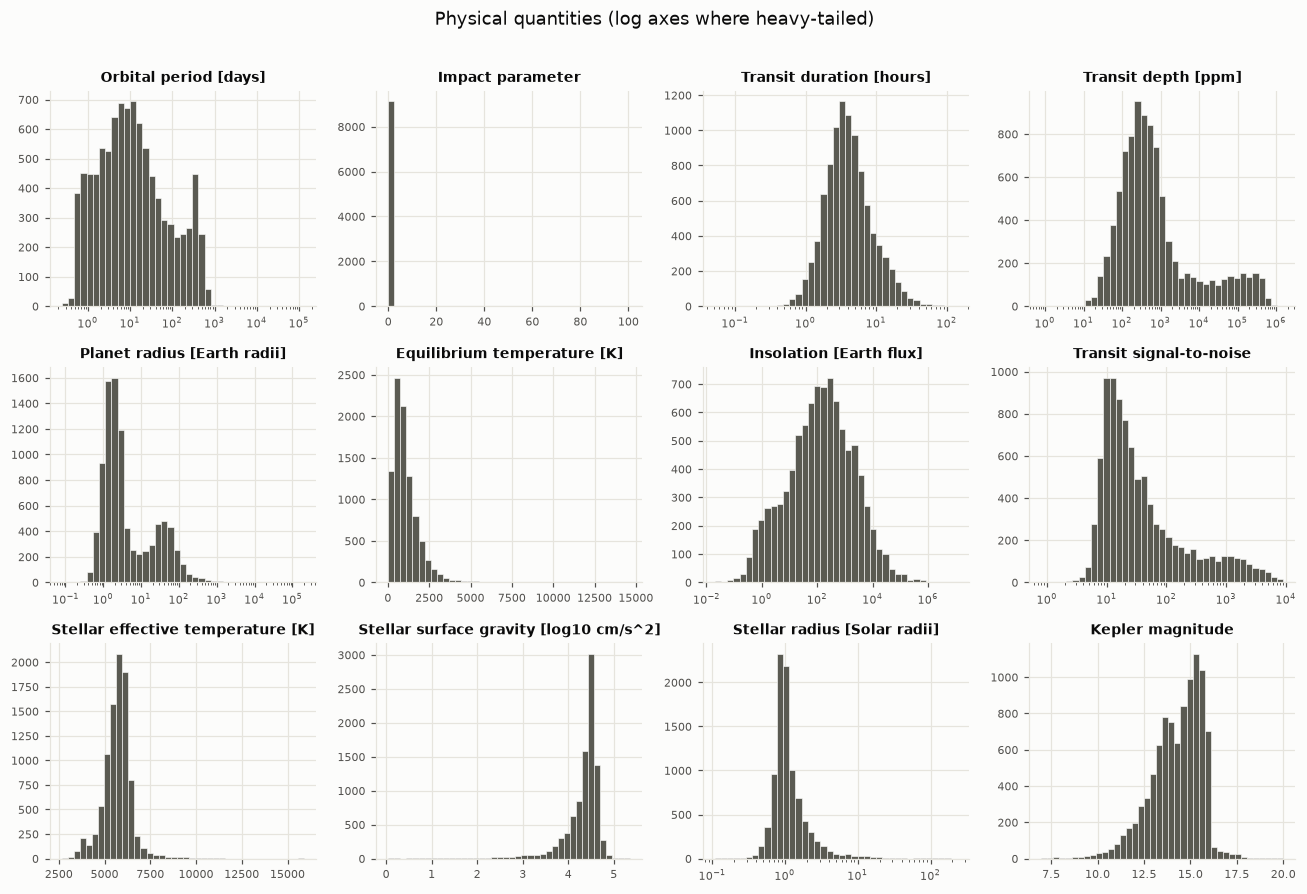

In [16]:
LOG_COLUMNS = {"koi_period", "koi_depth", "koi_prad", "koi_insol", "koi_model_snr", "koi_srad", "koi_duration"}
cols = preprocess.PHYSICS_COLUMNS
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, c in zip(axes.ravel(), cols):
    s = clean[c].dropna()
    if c in LOG_COLUMNS:
        s = s[s > 0]
        bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 40)
        ax.set_xscale("log")
    else:
        bins = 40
    ax.hist(s, bins=bins, color="#5a5a52", edgecolor=viz.SURFACE, linewidth=0.4)
    ax.set_title(label(c), fontsize=9)
    ax.tick_params(labelsize=7.5)
fig.suptitle("Physical quantities (log axes where heavy-tailed)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms_physics.png")
plt.show()

## 5. Save

The cleaned table keeps every KOI; model notebooks choose a feature set and decide about rows with `preprocess.model_table`.

In [17]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
out = DATA_PROCESSED / "koi_clean.parquet"
clean.to_parquet(out)
print("wrote", out.relative_to(out.parents[2]), clean.shape)

wrote data/processed/koi_clean.parquet (9564, 32)


## 6. The 2020 pipeline, reproduced

For the record: re-running the 2020 steps on the raw snapshot gives the same 8,945 × 24 table the old notebook pickled, so the Phase 2 baseline numbers can be tied to this code. `tests/test_preprocess.py` checks this on every run.

In [18]:
legacy = preprocess.to_legacy_names(preprocess.legacy_2020_processed(raw))
pickle_2020 = pd.read_pickle(data.DATA_RAW.parent / "legacy" / "kepler_processed.pkl")
same = legacy.index.equals(pickle_2020.index) and np.allclose(legacy.to_numpy(float), pickle_2020.to_numpy(float))
print("2020 processed table reproduced exactly:", same, "| shape", legacy.shape, "| rows dropped by the 2020 pipeline:", len(raw) - len(legacy))

2020 processed table reproduced exactly: True | shape (8945, 24) | rows dropped by the 2020 pipeline: 619


## Summary

- 9,564 KOIs; target `koi_disposition` with classes CANDIDATE (0), CONFIRMED (1), FALSE POSITIVE (2).
- Nulls are structural: 363 KOIs lack fitted parameters, 346 lack a delivery name; a `dropna` on the physics columns costs 364 rows, on the 2020 columns 619, and mostly false positives either way.
- The four vetting flags are the answer in disguise; `kepler_name` is a CONFIRMED proxy; `koi_teq` duplicates `koi_insol`.
- Next: notebook 03 restates the 2020 baseline as macro and per-class f1 (with flags vs physics only).